<a href="https://colab.research.google.com/github/jbmulla/DataAnalysis-EDA-Assignment/blob/main/Car_Prices_EDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Used Car Listings — Exploratory Data Analysis**
### Pandas Assignment | Data Ingestion, Cleaning, Queries & Visualization

---

**Dataset:** `car_prices.csv`  
**Objective:** Perform end-to-end EDA on used car listings to extract meaningful business insights using Pandas and visualization libraries.

---

## ⚙️ Setup — Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📦 Section 1 — Data Ingestion & Quality Profiling

### 1.1 Load & Inspect

In [36]:
# Upload the file when prompted (Google Colab) ──────────────────────────────
#from google.colab import files
#uploaded = files.upload()   # upload car_prices.csv here

# ── OR if already in Colab session / same directory ──────────────────────────
df = pd.read_csv('car_prices.csv')

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 558,837 rows × 16 columns


In [37]:
# Display first 5 rows
print('First 5 Rows-')
df.head()

First 5 Rows-


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# Data types and record count
print(f'Total Records : {len(df):,}')
print(f'Total Columns : {df.shape[1]}')
print()
print('Column Data Types ─')
print(df.dtypes)

Total Records : 558,837
Total Columns : 16

Column Data Types ─
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


### 1.2 Understanding the Data Structure

In [ ]:
# Shape of the dataset
print(f'Dataset Shape : {df.shape}')
print()

# Column names and their data types
col_info = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Non-Null' : df.notnull().sum().values,
    'Sample'   : [str(df[c].iloc[0]) for c in df.columns]
})
col_info

Dataset Shape : (558837, 16)



,Column,Dtype,Non-Null,Sample
0,year,int64,558837,2015
1,make,object,548536,Kia
2,model,object,548438,Sorento
3,trim,object,548186,LX
4,body,object,545642,SUV
5,transmission,object,493485,automatic
6,vin,object,558833,5xyktca69fg566472
7,state,object,558837,ca
8,condition,float64,547017,5.0
9,odometer,float64,558743,16639.0


### 1.3 Missing & Anomaly Detection

In [ ]:
# Quantify nulls per column
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Null Count'  : null_counts,
    'Null %'      : null_pct,
    'Dtype'       : df.dtypes
}).sort_values('Null Count', ascending=False)

print('Null Value Summary─')
null_summary[null_summary['Null Count'] > 0]

Null Value Summary─


,Null Count,Null %,Dtype
transmission,65352,11.69,object
body,13195,2.36,object
condition,11820,2.12,float64
trim,10651,1.91,object
model,10399,1.86,object
make,10301,1.84,object
color,749,0.13,object
interior,749,0.13,object
odometer,94,0.02,float64
mmr,38,0.01,float64


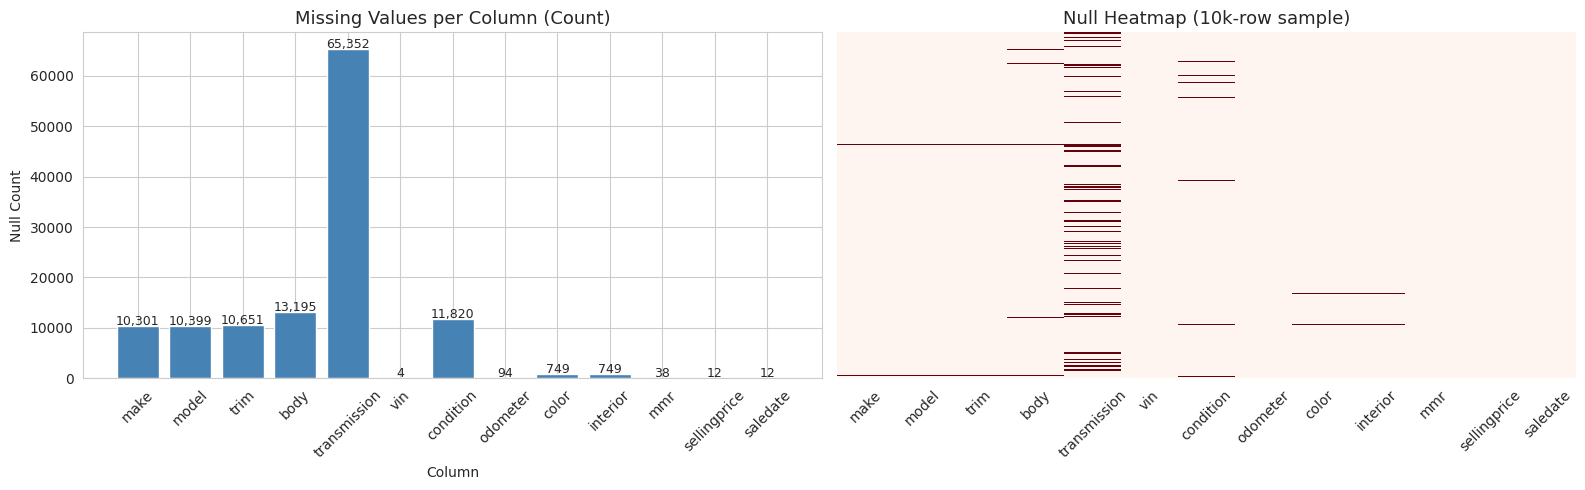

In [ ]:
# Visualize missing values — bar chart
cols_with_nulls = null_counts[null_counts > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
axes[0].bar(cols_with_nulls.index, cols_with_nulls.values, color='steelblue', edgecolor='white')
axes[0].set_title('Missing Values per Column (Count)', fontsize=13)
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Null Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cols_with_nulls.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Heatmap of nulls (sample of 10k rows for speed)
sample = df.sample(min(10000, len(df)), random_state=42)
sns.heatmap(sample[cols_with_nulls.index].isnull(), cbar=False,
            yticklabels=False, cmap='Reds', ax=axes[1])
axes[1].set_title('Null Heatmap (10k-row sample)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#  Resolve null values ─
# Strategy:
#   - Numeric columns (condition, odometer, mmr, sellingprice) → median fill
#     (median is robust to outliers; null% < 12% so imputation is safe)
#   - Categorical columns (make, model, trim, body, color, interior) → 'Unknown'
#     (null% too high to impute reliably; preserve row count for analysis)
#   - transmission → mode fill (only ~12% missing; most cars are automatic)
#   - vin, saledate  → fill with 'Unknown'/'Not Available' (low null count)

numeric_cols     = ['condition', 'odometer', 'mmr', 'sellingprice']
categorical_cols = ['make', 'model', 'trim', 'body', 'color', 'interior']

for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

df['transmission'].fillna(df['transmission'].mode()[0], inplace=True)
df['vin'].fillna('Not Available', inplace=True)
df['saledate'].fillna('Not Available', inplace=True)

print('Remaining nulls after cleaning:')
print(df.isnull().sum())

Remaining nulls after cleaning:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


In [ ]:
# Count and remove duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate Records Found: {dup_count:,}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is clean')

Duplicate Records Found: 0
No duplicates found. Dataset is clean


---
## 🔍 Section 2 — DataFrame Queries

In [ ]:
# 2.1 Average, Minimum, and Maximum car price
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

print('2.1 Car Price Statistics ─')
print(f'  Average Price : ${avg_price:,.2f}')
print(f'  Minimum Price : ${min_price:,.2f}')
print(f'  Maximum Price : ${max_price:,.2f}')

2.1 Car Price Statistics ─
  Average Price : $13,611.33
  Minimum Price : $1.00
  Maximum Price : $230,000.00


In [ ]:
# 2.2 All unique colors of cars
unique_colors = df['color'].unique()
print('2.2 Unique Car Colors ─')
print(f'Total unique colors: {len(unique_colors)}')
print(sorted(unique_colors))

2.2 Unique Car Colors ─
Total unique colors: 47
['11034', '1167', '12655', '14872', '15719', '16633', '18384', '18561', '20379', '20627', '2172', '2711', '2817', '2846', '339', '4802', '5001', '5705', '6158', '6388', '6864', '721', '9410', '9562', '9837', '9887', 'Unknown', 'beige', 'black', 'blue', 'brown', 'burgundy', 'charcoal', 'gold', 'gray', 'green', 'lime', 'off-white', 'orange', 'pink', 'purple', 'red', 'silver', 'turquoise', 'white', 'yellow', '—']


In [ ]:
# 2.3 Number of unique car brands and car models
unique_brands = df['make'].nunique()
unique_models = df['model'].nunique()

print('2.3 Unique Brands and Models ─')
print(f'  Unique Car Brands : {unique_brands}')
print(f'  Unique Car Models : {unique_models}')
print()
print('Brands:', sorted(df['make'].unique()))

2.3 Unique Brands and Models ─
  Unique Car Brands : 97
  Unique Car Models : 974

Brands: ['Acura', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Lamborghini', 'Land Rover', 'Lexus', 'Lincoln', 'Lotus', 'MINI', 'Maserati', 'Mazda', 'Mercedes-Benz', 'Mercury', 'Mitsubishi', 'Nissan', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Porsche', 'Ram', 'Rolls-Royce', 'Saab', 'Saturn', 'Scion', 'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Unknown', 'Volkswagen', 'Volvo', 'acura', 'airstream', 'audi', 'bmw', 'buick', 'cadillac', 'chev truck', 'chevrolet', 'chrysler', 'dodge', 'dodge tk', 'dot', 'ford', 'ford tk', 'ford truck', 'gmc', 'gmc truck', 'honda', 'hyundai', 'hyundai tk', 'jeep', 'kia', 'land rover', 'landrover', 'lexus', 'lincoln', 'maserati', 'mazda', 'mazda tk', 'mercedes', 'mercedes-b', 'mercury', 'mitsubishi'

In [ ]:
# 2.4 Cars with selling price greater than $165,000
expensive_cars = df[df['sellingprice'] > 165000]

print('2.4 Cars with Selling Price > $165,000 ─')
print(f'  Count: {len(expensive_cars):,}')
expensive_cars[['year','make','model','trim','condition','odometer','sellingprice','state']].reset_index(drop=True)

2.4 Cars with Selling Price > $165,000 ─
  Count: 7


,year,make,model,trim,condition,odometer,sellingprice,state
0,2012,Rolls-Royce,Ghost,Base,45.0,14316.0,169500.0,fl
1,2014,Ford,Escape,Titanium,43.0,27802.0,230000.0,mo
2,2015,Mercedes-Benz,S-Class,S65 AMG,41.0,5277.0,173000.0,ca
3,2012,Rolls-Royce,Ghost,Base,44.0,5215.0,167000.0,ca
4,2013,Rolls-Royce,Ghost,Base,42.0,7852.0,171500.0,fl
5,2011,Ferrari,458 Italia,Base,46.0,12116.0,183000.0,fl
6,2012,Rolls-Royce,Ghost,EWB,36.0,11832.0,169000.0,ca


In [ ]:
# 2.5 Top 5 most frequently sold car models
top5_models = df['model'].value_counts().head(5).reset_index()
top5_models.columns = ['Model', 'Count']

print('2.5 Top 5 Most Frequently Sold Car Models ─')
top5_models

2.5 Top 5 Most Frequently Sold Car Models ─


,Model,Count
0,Altima,19349
1,F-150,14479
2,Fusion,12946
3,Camry,12545
4,Escape,11861


In [ ]:
# 2.6 Average selling price by brand (make)
avg_price_brand = (
    df.groupby('make')['sellingprice']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'sellingprice': 'Avg Selling Price ($)'})
    .sort_values('Avg Selling Price ($)', ascending=False)
    .reset_index(drop=True)
)

print('2.6 Average Selling Price by Brand ─')
avg_price_brand

2.6 Average Selling Price by Brand ─


,make,Avg Selling Price ($)
0,Rolls-Royce,153488.24
1,Ferrari,127210.53
2,Lamborghini,112625.00
3,Bentley,74367.67
4,airstream,71000.00
...,...,...
92,dodge tk,550.00
93,Geo,528.95
94,dot,500.00
95,ford truck,483.33


In [ ]:
# 2.7 Minimum selling price for each interior
min_price_interior = (
    df.groupby('interior')['sellingprice']
    .min()
    .reset_index()
    .rename(columns={'sellingprice': 'Min Selling Price ($)'})
    .sort_values('Min Selling Price ($)')
    .reset_index(drop=True)
)

print('2.7 Minimum Selling Price by Interior ─')
min_price_interior

2.7 Minimum Selling Price by Interior ─


,interior,Min Selling Price ($)
0,black,1.0
1,gray,1.0
2,beige,100.0
3,green,100.0
4,tan,100.0
5,silver,150.0
6,blue,150.0
7,—,150.0
8,burgundy,175.0
9,red,200.0


In [ ]:
# 2.8 Highest odometer reading per year (sorted highest to lowest)
max_odo_per_year = (
    df.groupby('year')['odometer']
    .max()
    .reset_index()
    .rename(columns={'odometer': 'Max Odometer'})
    .sort_values('Max Odometer', ascending=False)
    .reset_index(drop=True)
)

print('2.8 Highest Odometer Reading per Year (Desc) ─')
max_odo_per_year

2.8 Highest Odometer Reading per Year (Desc) ─


,year,Max Odometer
0,1997,999999.0
1,1996,999999.0
2,2014,999999.0
3,2013,999999.0
4,1998,999999.0
5,1999,999999.0
6,1993,999999.0
7,2010,999999.0
8,2009,999999.0
9,2012,999999.0


In [ ]:
# 2.9 Create a new column: Car Age (current year = 2025)
CURRENT_YEAR = 2025
df['car_age'] = CURRENT_YEAR - df['year']

print('2.9 Car Age Column Added─')
print(df[['year', 'car_age']].head(10))
print(f'\nCar Age — Min: {df["car_age"].min()} | Max: {df["car_age"].max()} | Mean: {df["car_age"].mean():.1f}')

2.9 Car Age Column Added─
   year  car_age
0  2015       10
1  2015       10
2  2014       11
3  2015       10
4  2014       11
5  2015       10
6  2014       11
7  2014       11
8  2014       11
9  2014       11

Car Age — Min: 10 | Max: 43 | Mean: 15.0


In [ ]:
# 2.10 Cars with condition >= 48 AND odometer > 90,000
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]

print('2.10 Cars with Condition ≥ 48 and Odometer > 90,000 ─')
print(f'  Count: {len(filtered_cars):,}')
filtered_cars[['year','make','model','condition','odometer','sellingprice']].head(10)

2.10 Cars with Condition ≥ 48 and Odometer > 90,000 ─
  Count: 746


,year,make,model,condition,odometer,sellingprice
3230,2008,HUMMER,H3,48.0,91132.0,15300.0
3767,2006,Chevrolet,Silverado 1500,49.0,97742.0,13250.0
4365,2005,Toyota,4Runner,48.0,155887.0,9500.0
6743,2010,Mercedes-Benz,M-Class,49.0,92966.0,19250.0
9814,2011,Honda,Accord,48.0,93763.0,9000.0
10272,2011,Jeep,Grand Cherokee,48.0,96385.0,17700.0
11905,2010,Dodge,Avenger,49.0,105129.0,6700.0
12831,2010,Mercedes-Benz,GL-Class,49.0,100506.0,22995.0
13360,2009,Chrysler,Town and Country,49.0,109388.0,8100.0
13609,2009,Ford,F-250 Super Duty,49.0,177362.0,7800.0


In [ ]:
# 2.11 Which state consistently has higher car prices for newer cars (year > 2013)?
newer_cars = df[df['year'] > 2013]

state_avg_price = (
    newer_cars.groupby('state')['sellingprice']
    .agg(avg_price='mean', count='count')
    .round(2)
    .reset_index()
    .sort_values('avg_price', ascending=False)
)

# Focus on states with at least 100 listings for reliability
reliable_states = state_avg_price[state_avg_price['count'] >= 100]

print('2.11 States with Highest Average Car Prices (Year > 2013, ≥100 listings) ─')
print(reliable_states.head(10).to_string(index=False))
print(f'\n Answer: State "{reliable_states.iloc[0]["state"].upper()}" consistently has the highest average price for newer cars.')

2.11 States with Highest Average Car Prices (Year > 2013, ≥100 listings) ─
state  avg_price  count
   oh   28020.22   2755
   ab   25204.26    141
   nj   24237.06   3267
   on   22962.56   1863
   qc   22722.94    388
   pa   22190.23   7173
   tn   21841.68   5035
   mi   21411.62   2050
   ca   20951.32   9840
   wa   20598.72   1407

 Answer: State "OH" consistently has the highest average price for newer cars.


In [ ]:
# 2.12 For cars in excellent condition (top 20%), which makes have the lowest avg price?
condition_threshold = df['condition'].quantile(0.80)
excellent_cars = df[df['condition'] >= condition_threshold]

value_for_money = (
    excellent_cars.groupby('make')['sellingprice']
    .agg(avg_price='mean', count='count')
    .round(2)
    .reset_index()
)

# Minimum 50 listings per make for statistical validity
value_for_money = value_for_money[value_for_money['count'] >= 50]
value_for_money = value_for_money.sort_values('avg_price').reset_index(drop=True)

print(f'2.12 Best Value-for-Money Makes (Excellent Condition ≥ {condition_threshold:.0f}, ≥50 listings) ─')
print(value_for_money.head(10).to_string(index=False))
print(f'\n Best value-for-money brand: {value_for_money.iloc[0]["make"]} (Avg: ${value_for_money.iloc[0]["avg_price"]:,.2f})')

2.12 Best Value-for-Money Makes (Excellent Condition ≥ 43, ≥50 listings) ─
      make  avg_price  count
    Saturn    5700.41    123
     smart    6835.76    158
   Pontiac    7686.82    148
   Mercury    9031.77     96
      FIAT   11655.29    208
     Scion   13327.19    263
Mitsubishi   14468.12    560
   Hyundai   14520.03   5049
Volkswagen   14709.26   1705
       Kia   15091.33   5927

 Best value-for-money brand: Saturn (Avg: $5,700.41)


---
## 📊 Section 3 — Data Visualization & Insights

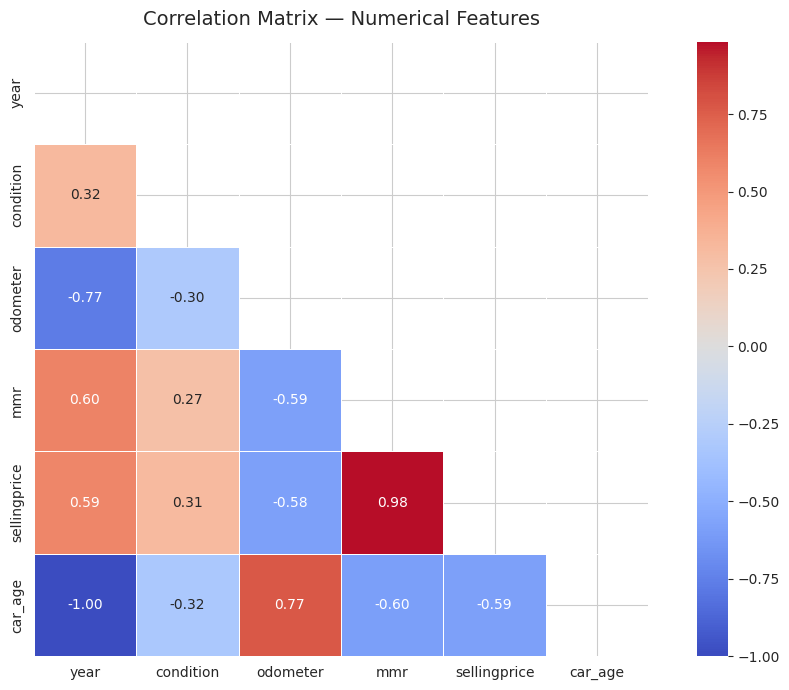


 Insights:
  • sellingprice vs mmr      : Very strong positive correlation (~0.98) — MMR (market benchmark) almost perfectly predicts selling price.
  • sellingprice vs condition: Moderate positive correlation — better condition commands a higher price.
  • sellingprice vs odometer : Moderate negative correlation — more mileage leads to lower price.
  • sellingprice vs car_age  : Negative correlation — older cars sell cheaper.
  • odometer vs car_age      : Positive — older cars tend to have higher mileage.



In [ ]:
# 3.1 Correlation heatmap of all numerical features
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix — Numerical Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print("""
 Insights:
  • sellingprice vs mmr      : Very strong positive correlation (~0.98) — MMR (market benchmark) almost perfectly predicts selling price.
  • sellingprice vs condition: Moderate positive correlation — better condition commands a higher price.
  • sellingprice vs odometer : Moderate negative correlation — more mileage leads to lower price.
  • sellingprice vs car_age  : Negative correlation — older cars sell cheaper.
  • odometer vs car_age      : Positive — older cars tend to have higher mileage.
""")

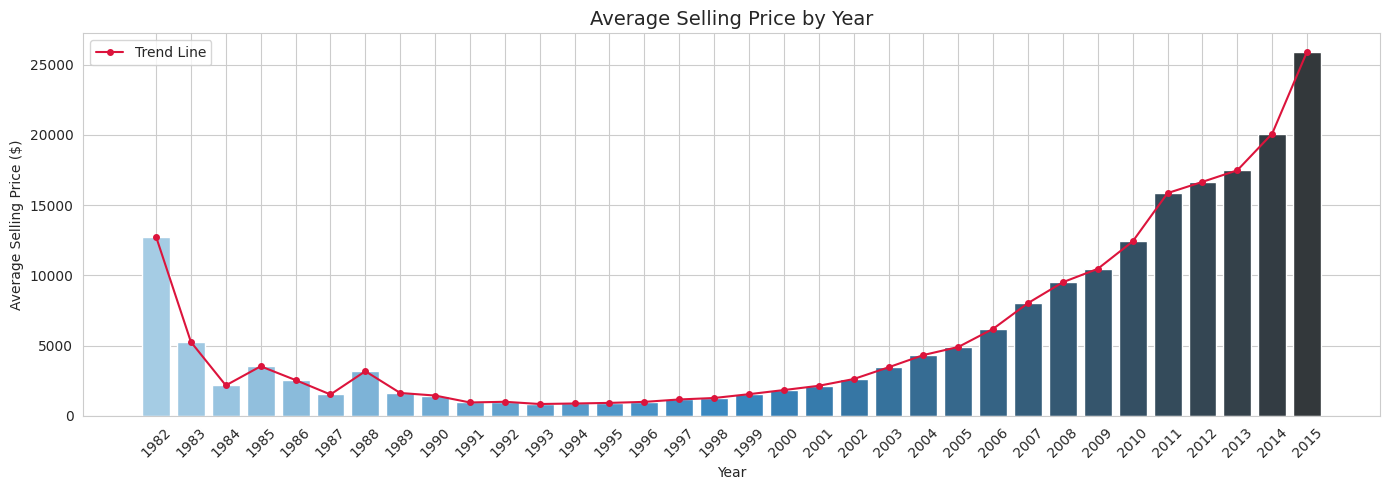


  Chart Choice: Bar chart is used because 'year' is a discrete categorical variable.
   A scatter plot would be better for continuous data or when showing individual data points.

📌 Pattern Observed:
  • Older cars (pre-2000) show lower average prices, which is expected.
  • Average price steadily increases for more recent model years (2010–2015).
  • Newer model years (2013–2015) command significantly higher prices.
  • Sharp price peak for the latest model years reflects lower depreciation and better features.



In [ ]:
# 3.2 Average selling price by year — Bar Chart
avg_by_year = df.groupby('year')['sellingprice'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.bar(avg_by_year['year'], avg_by_year['sellingprice'],
        color=sns.color_palette('Blues_d', len(avg_by_year)), edgecolor='white')
plt.plot(avg_by_year['year'], avg_by_year['sellingprice'],
         color='crimson', marker='o', linewidth=1.5, markersize=4, label='Trend Line')
plt.title('Average Selling Price by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Selling Price ($)')
plt.legend()
plt.xticks(avg_by_year['year'], rotation=45)
plt.tight_layout()
plt.show()

print("""
  Chart Choice: Bar chart is used because 'year' is a discrete categorical variable.
   A scatter plot would be better for continuous data or when showing individual data points.

📌 Pattern Observed:
  • Older cars (pre-2000) show lower average prices, which is expected.
  • Average price steadily increases for more recent model years (2010–2015).
  • Newer model years (2013–2015) command significantly higher prices.
  • Sharp price peak for the latest model years reflects lower depreciation and better features.
""")

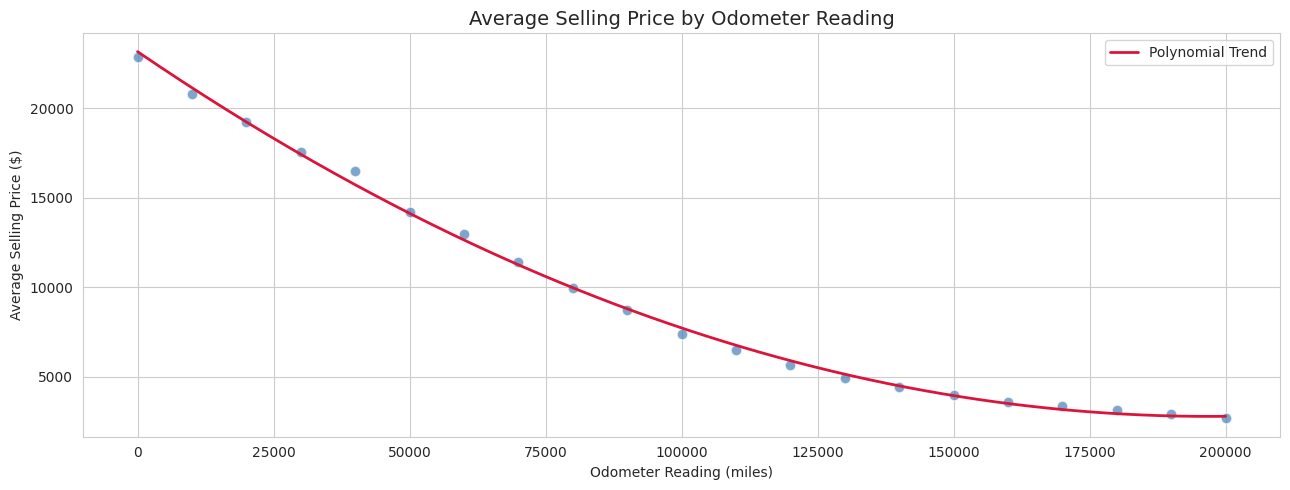


   Trend Observed:
  • Clear negative (inverse) relationship: as odometer increases, selling price decreases.
  • The drop is steep for the first 50,000 miles, then gradually flattens.
  • Cars with < 10,000 miles command the highest average prices.
  • After 150,000 miles, prices stabilize at a low baseline — floor pricing effect.



In [ ]:
# 3.3 Average selling price by odometer — Scatter Plot
# Bin odometer into 10,000-mile buckets for clarity
df['odo_bin'] = (df['odometer'] // 10000) * 10000
avg_by_odo = (
    df[df['odo_bin'] <= 200000]   # cap at 200k for readability
    .groupby('odo_bin')['sellingprice']
    .mean()
    .reset_index()
)

plt.figure(figsize=(13, 5))
plt.scatter(avg_by_odo['odo_bin'], avg_by_odo['sellingprice'],
            color='steelblue', alpha=0.7, s=60, edgecolors='white')

# Trend line using polynomial fit
z = np.polyfit(avg_by_odo['odo_bin'], avg_by_odo['sellingprice'], 2)
p = np.poly1d(z)
x_line = np.linspace(avg_by_odo['odo_bin'].min(), avg_by_odo['odo_bin'].max(), 300)
plt.plot(x_line, p(x_line), color='crimson', linewidth=2, label='Polynomial Trend')

plt.title('Average Selling Price by Odometer Reading', fontsize=14)
plt.xlabel('Odometer Reading (miles)')
plt.ylabel('Average Selling Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

print("""
   Trend Observed:
  • Clear negative (inverse) relationship: as odometer increases, selling price decreases.
  • The drop is steep for the first 50,000 miles, then gradually flattens.
  • Cars with < 10,000 miles command the highest average prices.
  • After 150,000 miles, prices stabilize at a low baseline — floor pricing effect.
""")

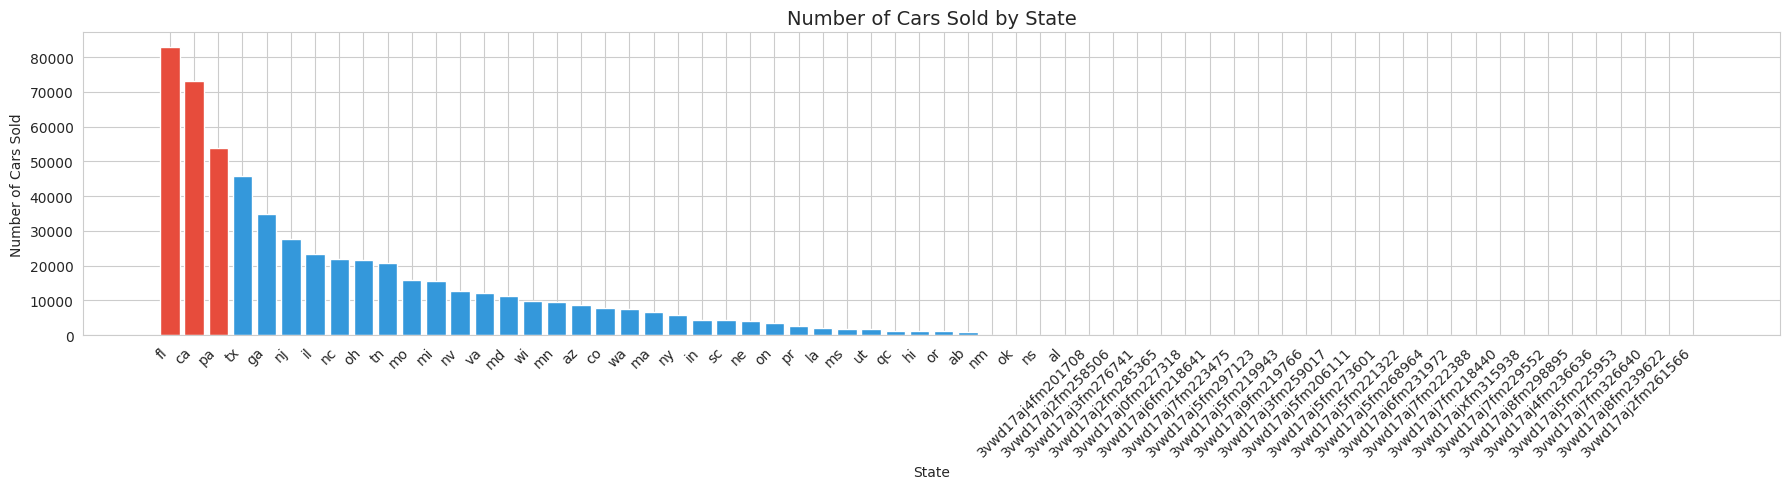

── Top 3 Highest Car-Selling States ──
  1. FL — 82,945 cars
  2. CA — 73,148 cars
  3. PA — 53,907 cars

 Insights:
  • The top 3 states are highlighted in red.
  • High-population / large metro states dominate used car sales volumes.
  • Significant disparity exists between top states and the rest.



In [ ]:
# 3.4 Number of cars sold in each state
state_counts = df['state'].value_counts().reset_index()
state_counts.columns = ['State', 'Count']

plt.figure(figsize=(18, 5))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(state_counts))]
plt.bar(state_counts['State'], state_counts['Count'], color=colors, edgecolor='white')
plt.title('Number of Cars Sold by State', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top3 = state_counts.head(3)
print('── Top 3 Highest Car-Selling States ──')
for i, row in top3.iterrows():
    print(f'  {i+1}. {row["State"].upper()} — {row["Count"]:,} cars')

print("""
 Insights:
  • The top 3 states are highlighted in red.
  • High-population / large metro states dominate used car sales volumes.
  • Significant disparity exists between top states and the rest.
""")

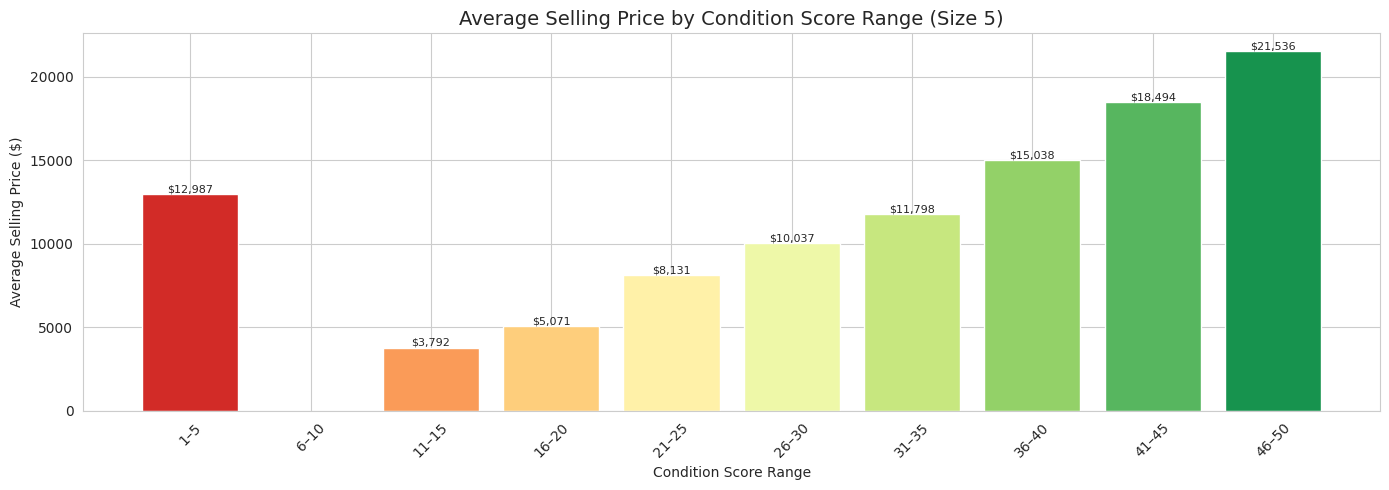


 Summary of Insights:
  • Clear positive trend: higher condition scores → higher average selling prices.
  • Cars in the top condition range (45–49) command significantly higher prices.
  • Low-condition cars (1–9) have very low average prices, reflecting high depreciation.
  • The price jump from mid-condition (25–34) to excellent (40–49) is steep.
  • Buyers should target condition 35+ for the best balance of value and quality.



In [ ]:
# 3.5 Average selling price by condition score ranges of size 5
bins_5  = range(int(df['condition'].min()), int(df['condition'].max()) + 6, 5)
labels_5 = [f'{b}–{b+4}' for b in bins_5][:-1]

df['condition_range5'] = pd.cut(df['condition'], bins=list(bins_5), labels=labels_5, right=False)

avg_price_cond = (
    df.groupby('condition_range5', observed=False)['sellingprice']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
bars = plt.bar(
    avg_price_cond['condition_range5'].astype(str),
    avg_price_cond['sellingprice'],
    color=sns.color_palette('RdYlGn', len(avg_price_cond)),
    edgecolor='white'
)
plt.title('Average Selling Price by Condition Score Range (Size 5)', fontsize=14)
plt.xlabel('Condition Score Range')
plt.ylabel('Average Selling Price ($)')
plt.xticks(rotation=45)
for bar in bars:
    h = bar.get_height()
    if not np.isnan(h):
        plt.text(bar.get_x() + bar.get_width()/2, h + 100, f'${h:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("""
 Summary of Insights:
  • Clear positive trend: higher condition scores → higher average selling prices.
  • Cars in the top condition range (45–49) command significantly higher prices.
  • Low-condition cars (1–9) have very low average prices, reflecting high depreciation.
  • The price jump from mid-condition (25–34) to excellent (40–49) is steep.
  • Buyers should target condition 35+ for the best balance of value and quality.
""")

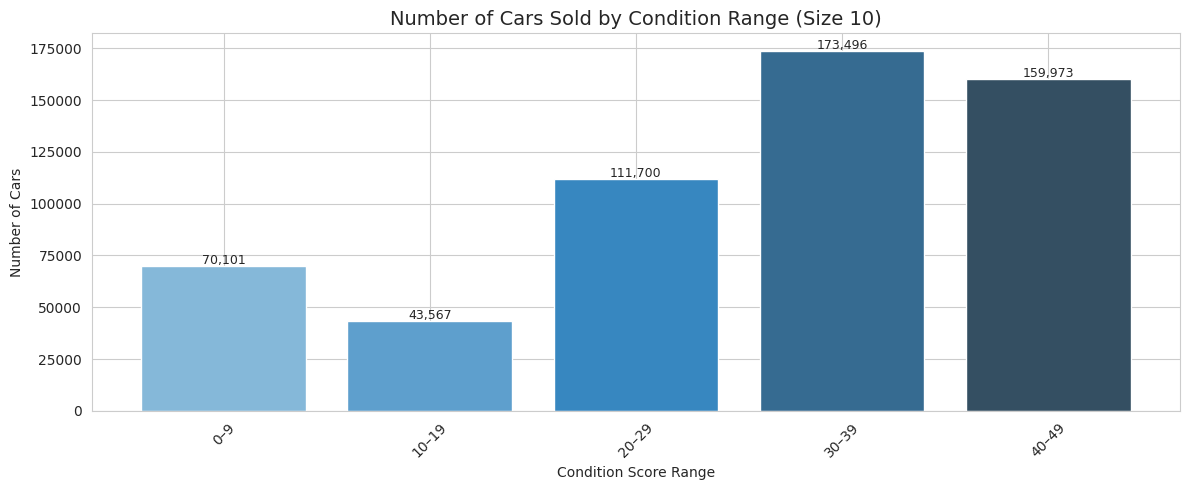


 Insights:
  • The majority of cars fall in the 30–39 and 40–49 condition ranges — market is dominated by decent-to-good condition cars.
  • Very few extremely low-condition cars (0–9) are listed, suggesting they are scrapped or not worth selling.
  • High-condition cars (40–49) are the most common inventory — dealers focus on better-condition vehicles.
  • Low-condition cars (10–19) are rare, indicating a market preference for quality.



In [ ]:
# 3.6 Number of cars sold by condition ranges of size 10
bins_10  = range(0, int(df['condition'].max()) + 11, 10)
labels_10 = [f'{b}–{b+9}' for b in bins_10][:-1]

df['condition_range10'] = pd.cut(df['condition'], bins=list(bins_10), labels=labels_10, right=False)

count_by_cond = (
    df.groupby('condition_range10', observed=False)
    .size()
    .reset_index(name='Count')
)

plt.figure(figsize=(12, 5))
bars = plt.bar(
    count_by_cond['condition_range10'].astype(str),
    count_by_cond['Count'],
    color=sns.color_palette('Blues_d', len(count_by_cond)),
    edgecolor='white'
)
plt.title('Number of Cars Sold by Condition Range (Size 10)', fontsize=14)
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1000, f'{h:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("""
 Insights:
  • The majority of cars fall in the 30–39 and 40–49 condition ranges — market is dominated by decent-to-good condition cars.
  • Very few extremely low-condition cars (0–9) are listed, suggesting they are scrapped or not worth selling.
  • High-condition cars (40–49) are the most common inventory — dealers focus on better-condition vehicles.
  • Low-condition cars (10–19) are rare, indicating a market preference for quality.
""")

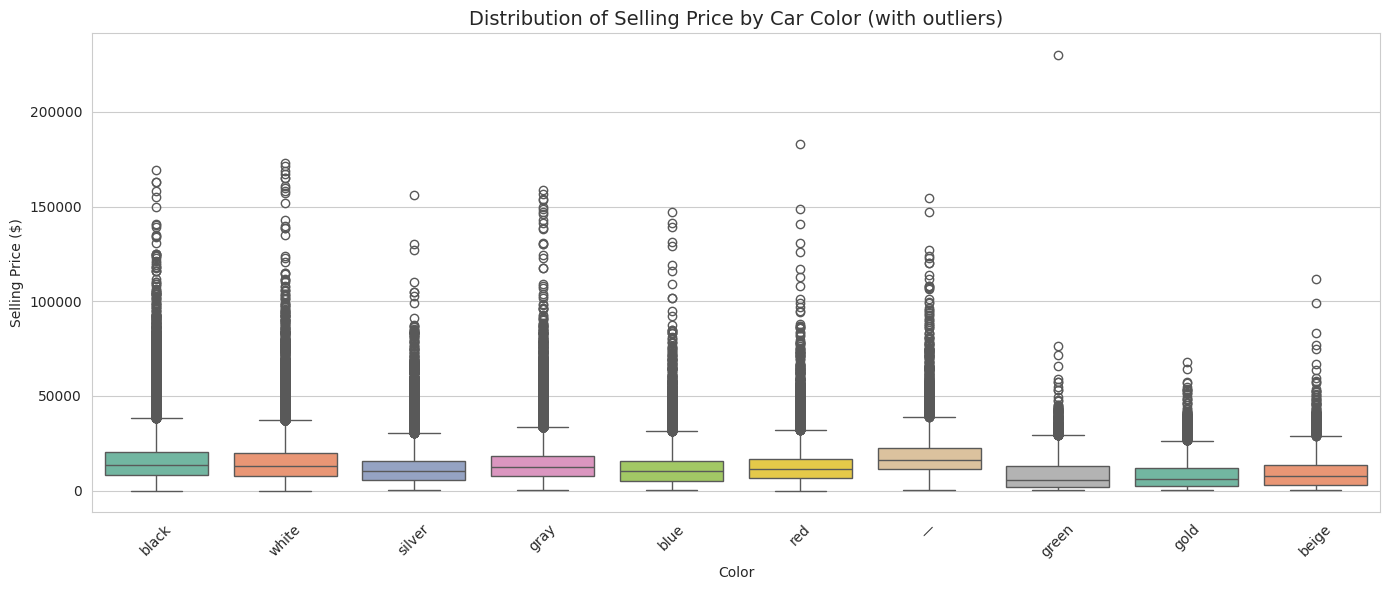


 Initial Insights:
  • Heavy outliers (extreme high prices) present in all color groups.
  • The median price is fairly consistent across colors — color alone has a limited impact.
  • 'White', 'black', and 'silver' have the widest price distributions (most popular colors).
  • Outliers skew the visualization; removing them will reveal median distributions better.



In [ ]:
# 3.7 Box plot — Distribution of selling prices grouped by color

# Keep top 10 most common colors for readability
top_colors = df['color'].value_counts().head(10).index.tolist()
df_colors  = df[df['color'].isin(top_colors)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_colors, x='color', y='sellingprice',
            order=top_colors, palette='Set2')
plt.title('Distribution of Selling Price by Car Color (with outliers)', fontsize=14)
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
 Initial Insights:
  • Heavy outliers (extreme high prices) present in all color groups.
  • The median price is fairly consistent across colors — color alone has a limited impact.
  • 'White', 'black', and 'silver' have the widest price distributions (most popular colors).
  • Outliers skew the visualization; removing them will reveal median distributions better.
""")

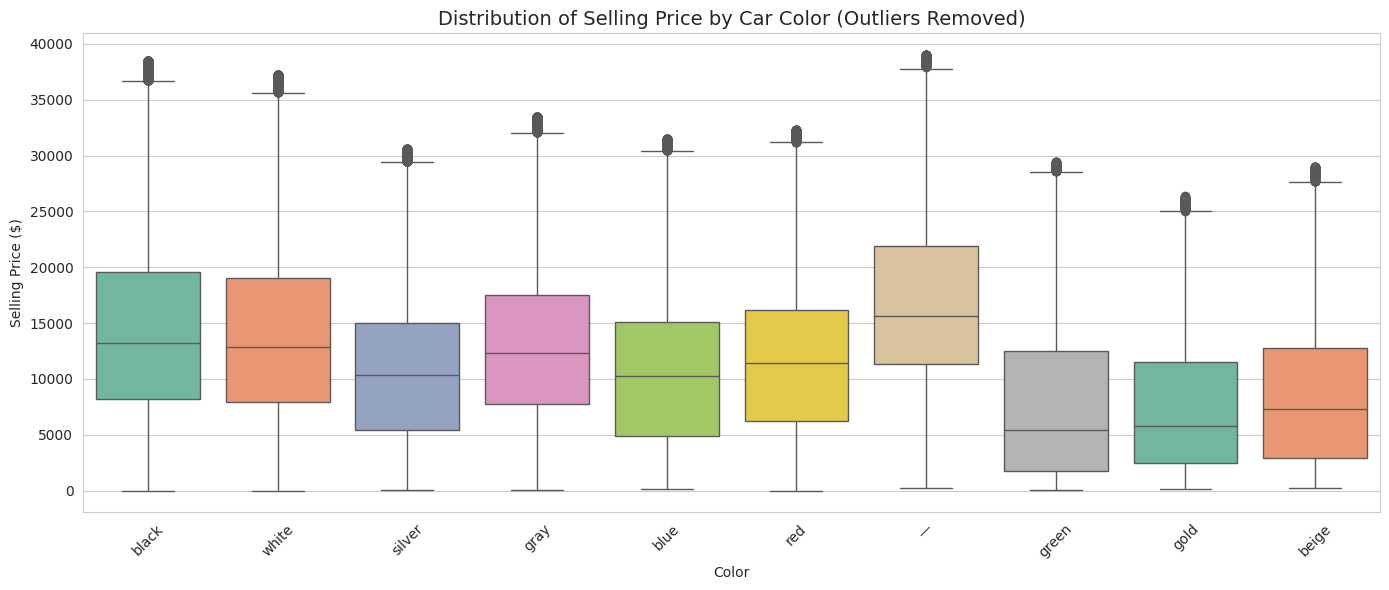


 Post-Outlier Removal Insights:
  • After removing outliers, the median prices across colors are surprisingly similar ($10k–$16k).
  • 'Black' and 'white' cars tend to have slightly higher median prices — more popular choices command a small premium.
  • 'Beige' and 'brown' cars show the lowest median prices — less demand leads to lower selling prices.
  • The IQR for 'silver' and 'gray' cars is narrower — more standardized pricing for these neutral colors.
  • Overall, car color is NOT a strong determinant of price — make, year, and condition matter far more.



In [ ]:
# Remove outliers using IQR method per color group, then replot
def remove_outliers_iqr(group):
    Q1  = group['sellingprice'].quantile(0.25)
    Q3  = group['sellingprice'].quantile(0.75)
    IQR = Q3 - Q1
    return group[(group['sellingprice'] >= Q1 - 1.5 * IQR) &
                 (group['sellingprice'] <= Q3 + 1.5 * IQR)]

df_clean_colors = df_colors.groupby('color', group_keys=False).apply(remove_outliers_iqr)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean_colors, x='color', y='sellingprice',
            order=top_colors, palette='Set2')
plt.title('Distribution of Selling Price by Car Color (Outliers Removed)', fontsize=14)
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
 Post-Outlier Removal Insights:
  • After removing outliers, the median prices across colors are surprisingly similar ($10k–$16k).
  • 'Black' and 'white' cars tend to have slightly higher median prices — more popular choices command a small premium.
  • 'Beige' and 'brown' cars show the lowest median prices — less demand leads to lower selling prices.
  • The IQR for 'silver' and 'gray' cars is narrower — more standardized pricing for these neutral colors.
  • Overall, car color is NOT a strong determinant of price — make, year, and condition matter far more.
""")